In [143]:
from network_module import WeightedNetwork, AbstractNode, Message, visualize_graph
import networkx as nx
from enum import Enum

In [ ]:
class NodeState(Enum):
    FIND = "find"
    FOUND = "found"

class EdgeState(Enum):
    REJECTED = "rejected"
    BRANCH = "branch"
    BASIC = "basic"

class MessageRequest(Enum):
    CONNECT = "connect"
    INITIATE = "initiate"
    TEST = "test"
    ACCEPT = "accept"
    REJECT = "reject"

The point of a connect message is that a fragment wants to try and merge over their MOE. The connect message is sent by the node adjacent to the MOE of the fragment to the node that is also adjacent to the edge (in a different fragment? I would assume so otherwise its not a MOE).

When a node recieves a connect message there are a couple situations.
1. The fragment you're trying to connect to is at a higher level and therefore you'll be absorbed into that fragment
   1. In which case initate messages are flooded to this fragment
2. The two fragments both send connect messages over the edges (this edge is the MOE of both fragments and therefore both labels set the status of this edge to be Branch)

The code here has the notion of find and found to stop fragments form waiting

I have a feeling find count is there such that the node knows how many ndoes to recieve convergecast messages from given that it told these nodes to go find MOE.


TODO: its bad that to know where a message came from the sender has to append this to the content of their message.

In [ ]:
class GHSNode(AbstractNode):
    def __init__(self, node_id, neighbours):
        super().__init__(node_id, neighbours)
        self.state["fragment_id"] = None
        self.state["phase"] = NodeState.FIND
        self.state["fragment_level"] = 0
        self.state["adjacent_edges"] = {
            neighbor: {"status": EdgeState.BASIC, "weight": weight}
            for neighbor, weight in self._neighbours.items()
        }
        self.state["message_queue"] = []

    def _startup(self) -> None:
        # find the neighbouring node that corresponds to the minimum weight adjacent edge
        min_node = min(
            (
                node
                for node, info in self.state["adjacent_edges"].items()
                if info["status"] == EdgeState.BASIC
            ),
            key=lambda node: self.state["adjacent_edges"][node]["weight"],
            default=None,
        )

        # mark the edge as a branch of the MST
        if min_node is not None:
            self.state["adjacent_edges"][min_node]["status"] = EdgeState.BRANCH

        self.state["phase"] = NodeState.FOUND

        self.send_message(
            min_node,
            {"request": MessageRequest.CONNECT, "id": self.node_id, "level": 0},
        )

        print(
            f"My minimum outgoing edge ({self.node_id}, {min_node}) with weight {self.state["adjacent_edges"][min_node]["weight"]}"
        )

    def _on_connect(self, message: Message) -> None:
        if message.content["level"] < self.state["fragment_level"]:
            self.state["adjacent_edges"][message.content["id"]][
                "status"
            ] = EdgeState.BRANCH
            self.send_message(
                message.content["id"],
                {
                    "request": MessageRequest.INITIATE,
                    "id": self.node_id,
                    "fragment_level": self.state["fragment_level"],
                    "fragment_id": self.state["fragment_id"],
                    "phase": self.state["phase"],
                },
            )
        elif (
            self.state["adjacent_edges"][message.content["id"]]["status"]
            == EdgeState.BASIC
        ):
            self.state["message_queue"].append(message)

        # else they've both selected each other
        else:
            # merge the fragment by flooding initate messages within the two fragments
            # remember both nodes are trying to connect with each other
            # therefore the messages will be flooded to all nodes in both fragments as
            # each node is sending the initate messages
            # will go into phase find because its a new fragment trying to a MOE
            self.send_message(
                message.content["id"],
                {
                    "request": MessageRequest.INITIATE,
                    "id": self.node_id,
                    "fragment_level": self.state["fragment_level"] + 1,
                    "fragment_id": self.state["adjacent_edges"][message.content["id"]][
                        "weight"
                    ],
                    "phase": NodeState.FIND,
                },
            )

    def _on_initiate(self, message: Message) -> None:
        self.state.update(
            {
                "fragment_level": message.content["fragment_level"],
                "fragment_id": message.content["fragment_id"],
                "phase": message.content["phase"],
            }
        )

        for neighbor, edge_info in self.state["adjacent_edges"].items():
            if (
                edge_info["status"] == EdgeState.BRANCH
                and neighbor != message.content["id"]
            ):
                self.send_message(
                    neighbor,
                    {
                        "request": MessageRequest.INITIATE,
                        "fragment_level": message.content["fragment_level"],
                        "fragment_id": message.content["fragment_id"],
                        "phase": message.content["phase"],
                    },
                )

        # if the phase of the new fragment is Find then execute procedure test
        if message.content["phase"] == NodeState.FIND:
            self._test()

    def _test(self) -> None:
        basic_edges = sorted(
            [
                (neighbor, info["weight"])
                for neighbor, info in self.state["adjacent_edges"].items()
                if info["status"] == EdgeState.BASIC
            ],
            key=lambda x: x[1],
        )

        if basic_edges:
            test_edge = basic_edges[0]
            self.send_message(
                test_edge[0],
                {
                    "request": MessageRequest.TEST,
                    "id": self.node_id,
                    "fragment_level": self.state["fragment_level"],
                    "fragment_id": self.state["fragment_id"],
                },
            )
        else:
            test_edge = None
            # TODO: execute procedure report

        print(f"Basic edges: {basic_edges}")

    def _on_test(self, message: Message) -> None:
        fragment_level = message.content["fragment_level"]
        fragment_id = message.content["fragment_id"]
        sender_id = message.content["id"]

        if fragment_level > self.state["fragment_level"]:
            self.state["message_queue"].append(message)

        elif fragment_id != self.state["fragment_id"]:
            self.send_message(
                message.content["id"],
                {"request": MessageRequest.ACCEPT, "id": self.node_id},
            )
        # this is the case where the two nodes are in the same fragment already
        # therefore the edge between them cannot now be added to MST
        # it could however already be in the MST
        elif self.state["adjacent_edges"][sender_id]["status"] == EdgeState.BASIC:
            self.state["adjacent_edges"][sender_id]["status"] = EdgeState.REJECTED

            # TODO: add test_edge functionality (not sure what it does yet...)

            self.send_message(
                message.recipient,
                {"request": MessageRequest.REJECT, "id": self.node_id},
            )

    def _on_accept(self, message: Message) -> None:
        # TODO: requires the notion of best-wt which I currently don't understand
        # i think it has something to do with the process of a node finding a MOE
        # clearly as it works through some are rejected and we want to find the 
        # MOE from a node that is accepted
        pass

    def _on_reject(self, message: Message) -> None:
        """this makes sense so a reject message is sent following a test message
         a node sends a test message to see if an adjacent edge that as far as it knows
        hasn't been considered could be a MOE. The node that was sent the test
        message has realised that the two nodes are in the same fragment and they
        also have that edge as being not considered, therefore we can deduce that
         this edge can't be in the MST as its not the minimum edge that connected
        these two nodes originally."""
        if (
            self.state["adjacent_edges"][message.content["id"]]["status"]
            == EdgeState.BASIC
        ):
            self.state["adjacent_edges"][message.content["id"]][
                "status"
            ] = EdgeState.REJECTED

        self._test()

    def compute(self, round_number):
        print(f"{"*" * 30} Node {self.node_id} {"*" * 30}")
        # If no messages have arrived, inject a default message
        if not self.message_queue:
            self.message_queue.append(
                Message(recipient=self.node_id, content={"request": None})
            )

        # Process messages
        while self.message_queue:
            message = self.message_queue.pop(0)
            # Handle message content
            print(f"Processing message: {message.content}")

            # check if node is zero level fragment and it's the first round
            if round_number == 0 and self.state["fragment_level"] == 0:
                self._startup()

            # repsonse to reciept of connect message
            if message.content.get("request") == MessageRequest.CONNECT:
                self._on_connect(message)

            # response to reciept of initiate message
            if message.content.get("request") == MessageRequest.INITIATE:
                self._on_initiate(message)

            if message.content.get("request") == MessageRequest.TEST:
                self._on_test(message)

            if message.content.get("request") == MessageRequest.ACCEPT:
                self._on_accept(message)

            if message.content.get("request") == MessageRequest.REJECT:
                self._on_reject(message)

        print("-" * 100)

In [146]:
# Create an empty graph
G = nx.Graph()

# Add nodes
G.add_nodes_from([1, 2, 3, 4])

# Add edges with weights
G.add_edge(1, 2, weight=1.5)
G.add_edge(1, 3, weight=2.0)
G.add_edge(2, 3, weight=2.5)
G.add_edge(2, 4, weight=1.0)
G.add_edge(3, 4, weight=3.0)

In [147]:
network = WeightedNetwork(G, GHSNode)
network.run(4)
print(network)

****************************** Node 1 ******************************
Processing message: {'request': None}
My minimum outgoing edge (1, 2) with weight 1.5
----------------------------------------------------------------------------------------------------
****************************** Node 2 ******************************
Processing message: {'request': None}
My minimum outgoing edge (2, 4) with weight 1.0
----------------------------------------------------------------------------------------------------
****************************** Node 3 ******************************
Processing message: {'request': None}
My minimum outgoing edge (3, 1) with weight 2.0
----------------------------------------------------------------------------------------------------
****************************** Node 4 ******************************
Processing message: {'request': None}
My minimum outgoing edge (4, 2) with weight 1.0
-----------------------------------------------------------------------------

So,
- Node 1 will send a connect message to 2
- Node 2 will send a connect message to 4
- Node 3 will send a connect message to 1
- Node 4 will send a connect message to 2

So the only two nodes that send connect messages to each other are nodes 2 and 4.

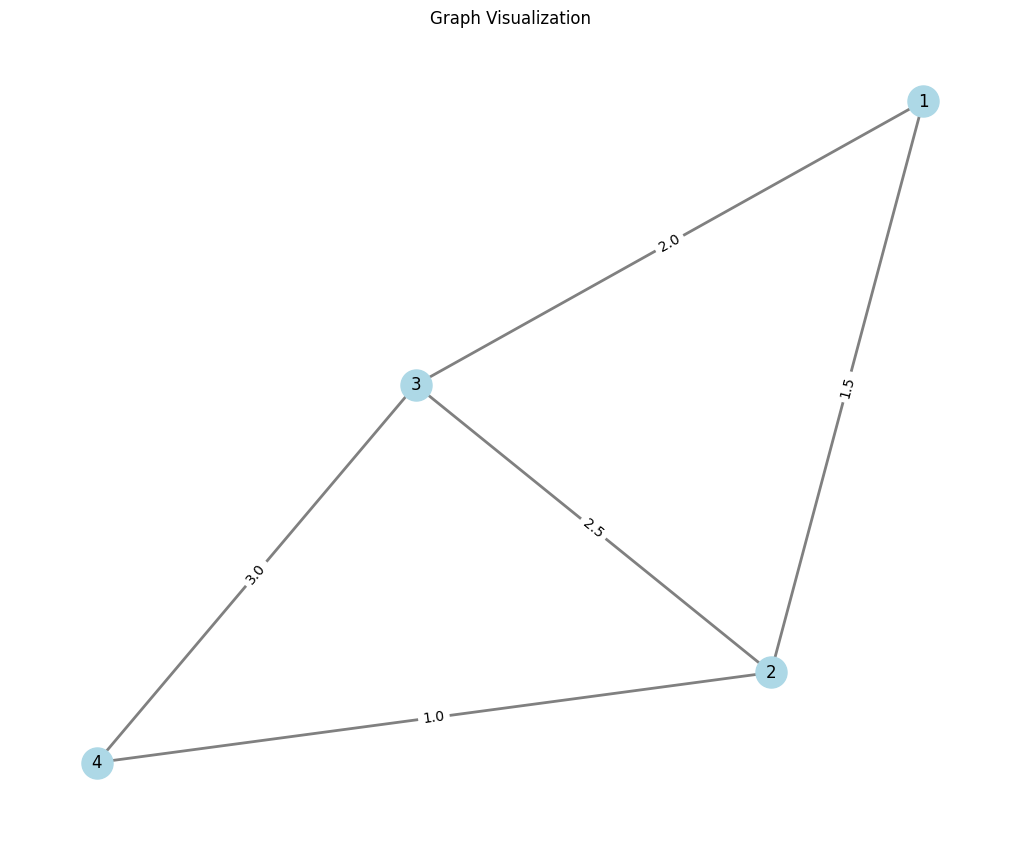

In [148]:
visualize_graph(G, network.nodes)